# **Q-learning**

Vamos usar um grid world 4x4 com um objetivo e uma armadilha, utilizando Q-learning para aprender o melhor caminho.

A visualização mostrará:

+ O mapa do ambiente (agente, objetivo, obstáculo)

+ A política aprendida (setas indicando a melhor ação em cada célula)

+ A evolução da recompensa total por episódio

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [10]:
seed = 22
random.seed(seed)
np.random.seed(seed)

# Ambiente

Tabuleiro quadriculado com 4 linhas e 4 colunas, onde cada célula representa um estado possível para o agente.

**Estados**

+ Início: onde o agente sempre começa cada episódio. Não oferece recompensa.

+ Meta: Ao alcançá-la, o agente recebe +1 de recompensa e o episódio termina imediatamente.

+ Armadilha: Se o agente pisar nela, recebe −1 e o episódio também termina.

+ Demais células: são neutras. O agente pode passar por elas sem ganhar ou perder recompensa, mas também sem encerrar o episódio.

**Ações**

+ O agente pode executar quatro ações: 'cima', 'baixo', 'esquerda' e 'direita'.
+ Cada ação desloca o agente uma célula na direção correspondente.

**OBS**.: O mundo é fechado. O agente não pode sair do grid. Se ele tentar um movimento que o levaria para fora, o ambiente o mantém na mesma posição.

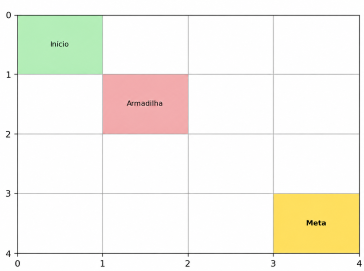

In [11]:
# ========================== AMBIENTE ==========================
class GridWorld:
    def __init__(self):
        self.rows = 4
        self.cols = 4
        self.start = (0, 0)
        self.goal = (3, 3)       # +1
        self.trap = (1, 1)      # -1
        self.actions = ['cima', 'baixo', 'esquerda', 'direita']

    def reset(self):
        return self.start

    def step(self, state, action):
        r, c = state # r: row, c: column
        if action == 'cima':
            r = max(r - 1, 0)
        elif action == 'baixo':
            r = min(r + 1, self.rows - 1)
        elif action == 'esquerda':
            c = max(c - 1, 0)
        elif action == 'direita':
            c = min(c + 1, self.cols - 1)

        next_state = (r, c)
        if next_state == self.goal:
            return next_state, 1.0, True
        elif next_state == self.trap:
            return next_state, -1.0, True
        else:
            return next_state, 0.0, False

## Q-learning

+ A tabela Q é inicializada com zeros e atualizada pela equação de Bellman.
+ Treinamento: 1000 episódios com Q‑learning (epsilon‑greedy).
  + epsilon: 0.5 -> 50% de chance de explorar ou explotar.
  + epsilon não decai ao longo dos episódios.


In [12]:
# ==================== Q-LEARNING ====================
env = GridWorld()
alpha = 0.1
gamma = 0.9
epsilon = 0.5
episodios = 1000

Q = {}
for r in range(env.rows):
    for c in range(env.cols):
        Q[(r, c)] = {a: 0.0 for a in env.actions}

recompensas_episodio = []

for ep in range(episodios):
    estado = env.reset()
    total_recompensa = 0
    terminou = False
    while not terminou:
        if random.random() < epsilon:
            acao = random.choice(env.actions)
        else:
            acao = max(Q[estado], key=Q[estado].get)

        prox_estado, recompensa, terminou = env.step(estado, acao)
        melhor_prox = max(Q[prox_estado].values())
        Q[estado][acao] += alpha * (recompensa + gamma * melhor_prox - Q[estado][acao])

        estado = prox_estado
        total_recompensa += recompensa
    recompensas_episodio.append(total_recompensa)

## Visualização

As figuras abaixo mostram:

+ Mapa com as células coloridas e setas indicando a melhor ação aprendida em cada estado.

+ Gráfico de recompensa por episódio que mostra como o agente passa a acumular +1 consistentemente quando aprende a evitar a armadilha.

Percebam que o agente aprendeu a contornar a armadilha.

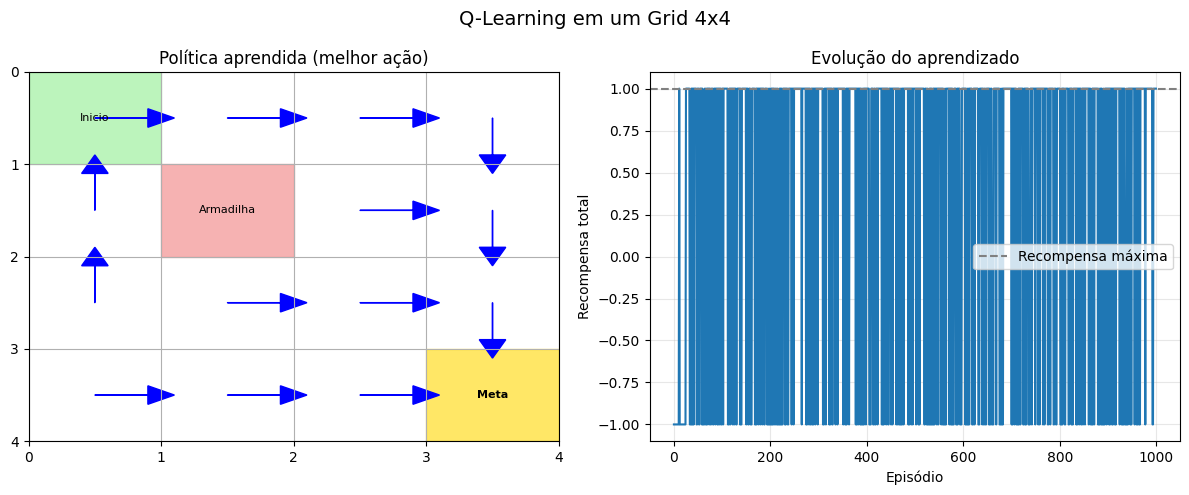

In [13]:
# ==================== VISUALIZAÇÃO ====================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Q-Learning em um Grid 4x4', fontsize=14)

# Mapa
ax1.set_xlim(0, env.cols)
ax1.set_ylim(0, env.rows)
ax1.set_xticks(np.arange(0, env.cols+1, 1))
ax1.set_yticks(np.arange(0, env.rows+1, 1))
ax1.grid(True)
ax1.set_title('Política aprendida (melhor ação)')
ax1.invert_yaxis()

for r in range(env.rows):
    for c in range(env.cols):
        if (r, c) == env.start:
            ax1.add_patch(plt.Rectangle((c, r), 1, 1, color='lightgreen', alpha=0.6))
            ax1.text(c+0.5, r+0.5, 'Inicio', ha='center', va='center', fontsize=8)
        elif (r, c) == env.goal:
            ax1.add_patch(plt.Rectangle((c, r), 1, 1, color='gold', alpha=0.6))
            ax1.text(c+0.5, r+0.5, 'Meta', ha='center', va='center', fontsize=8, fontweight='bold')
        elif (r, c) == env.trap:
            ax1.add_patch(plt.Rectangle((c, r), 1, 1, color='lightcoral', alpha=0.6))
            ax1.text(c+0.5, r+0.5, 'Armadilha', ha='center', va='center', fontsize=8)

# Setas da política
for estado in Q:
    if estado in [env.goal, env.trap]:
        continue
    melhor_acao = max(Q[estado], key=Q[estado].get)
    r, c = estado
    dx, dy = 0, 0
    if melhor_acao == 'cima':
        dy = -0.4
    elif melhor_acao == 'baixo':
        dy = 0.4
    elif melhor_acao == 'esquerda':
        dx = -0.4
    elif melhor_acao == 'direita':
        dx = 0.4
    ax1.arrow(c+0.5, r+0.5, dx, dy, head_width=0.2, head_length=0.2, fc='blue', ec='blue')

# Curva de aprendizado
ax2.plot(recompensas_episodio)
ax2.set_xlabel('Episódio')
ax2.set_ylabel('Recompensa total')
ax2.set_title('Evolução do aprendizado')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=1.0, color='gray', linestyle='--', label='Recompensa máxima')
ax2.legend()

plt.tight_layout()
plt.show()

## Exemplos de valores tabela Q após a aprendizado

In [14]:
# Exemplo da tabela Q
print("Exemplo da tabela Q (estado (0,0)):")
for acao, valor in Q[(0,0)].items():
    print(f"  {acao}: {valor:.3f}")

Exemplo da tabela Q (estado (0,0)):
  cima: 0.531
  baixo: 0.478
  esquerda: 0.531
  direita: 0.590


In [15]:
# Exemplo da tabela Q
print("Exemplo da tabela Q (estado (1,1)):")
for acao, valor in Q[(1,1)].items():
    print(f"  {acao}: {valor:.3f}")

Exemplo da tabela Q (estado (1,1)):
  cima: 0.000
  baixo: 0.000
  esquerda: 0.000
  direita: 0.000


In [16]:
# Exemplo da tabela Q
print("Exemplo da tabela Q (estado (2,3)):")
for acao, valor in Q[(2,3)].items():
    print(f"  {acao}: {valor:.3f}")

Exemplo da tabela Q (estado (2,3)):
  cima: 0.810
  baixo: 1.000
  esquerda: 0.802
  direita: 0.900
